In [1]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
#from tensorflow.keras.utils import plot_model
from datetime import timedelta
from pathlib import Path

import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

import tensorflow as tf
#import visualkeras
import warnings
import time

# Configuraciones
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
sns.color_palette("colorblind")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
tf.__version__

'2.19.0'

In [3]:
!nvidia-smi

Sat Nov 22 19:42:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [45]:
! ls

history  models  results  sample_data


In [46]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("history", exist_ok=True)

In [47]:
class ProcessAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
        
        self.processes = {
            'P1': {
                'name': 'Raw Water Tank',
                'sensors': ['FIT101', 'LIT101'],
                'actuators': ['MV101', 'P101', 'P102'],
                'color': '#3498db'
            },
            'P2': {
                'name': 'UF Feed',
                'sensors': ['AIT201', 'AIT202', 'AIT203', 'FIT201'],
                'actuators': ['MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206'],
                'color': '#e74c3c'
            },
            'P3': {
                'name': 'Ultrafiltration',
                'sensors': ['AIT301', 'AIT302', 'AIT303', 'DPIT301', 'FIT301', 'LIT301'],
                'actuators': ['MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302'],
                'color': '#2ecc71'
            },
            'P4': {
                'name': 'Dechlorination',
                'sensors': ['AIT401', 'AIT402', 'FIT401', 'LIT401'],
                'actuators': ['P401', 'P402', 'P403', 'P404', 'UV401'],
                'color': '#f39c12'
            },
            'P5': {
                'name': 'Reverse Osmosis',
                'sensors': ['AIT501', 'AIT502', 'AIT503', 'AIT504',
                            'FIT501', 'FIT502', 'FIT503', 'FIT504',
                            'PIT501', 'PIT502', 'PIT503'],
                'actuators': ['MV501', 'MV502', 'MV503', 'MV504', 'P501', 'P502'],
                'color': '#9b59b6'
            },
            'P6': {
                'name': 'Product Water',
                'sensors': ['FIT601', 'FIT602', 'LIT601', 'LIT602'],
                'actuators': ['P601', 'P602', 'P603'],
                'color': '#1abc9c'
            }
        }
    
    def get_event_range(self, event_id):
        event_data = self.df[self.df['Anomaly_Event'] == event_id]
        if len(event_data) == 0:
            return None, None
        return event_data.index.min(), event_data.index.max()
    
    def get_window(self, event_id, seconds_before=600, seconds_after=300):
        event_start, event_end = self.get_event_range(event_id)
        if event_start is None:
            print(f"Evento {event_id} no encontrado")
            return None, None, None, None, None
        
        start = event_start - timedelta(seconds=seconds_before)
        end = event_end + timedelta(seconds=seconds_after)
        window = self.df.loc[start:end]
        
        return window, start, end, event_start, event_end

    def _select_variables(self, pinfo, df_window, mode):
        """
        Selecciona columnas a graficar según el modo:
        sensors / actuators / both
        """
        to_plot = []

        if mode in ["sensors", "both"]:
            to_plot.extend([s for s in pinfo["sensors"] if s in df_window.columns])

        if mode in ["actuators", "both"]:
            to_plot.extend([a for a in pinfo["actuators"] if a in df_window.columns])

        # Mantener máximo 3 para que tu diseño no explote
        return to_plot[:3]

    def plot_all_processes(self, event_id, seconds_before=600, seconds_after=300, mode="sensors"):
        window, start, end, event_start, event_end = self.get_window(event_id, seconds_before, seconds_after)
        if window is None:
            return
        
        fig, axes = plt.subplots(6, 1, figsize=(18, 16), sharex=True)
        
        event_dets = window[window['Anomaly_Event'] == event_id]['Detectors'].iloc[0] if 'Detectors' in window.columns else ''
        
        fig.suptitle(
            f"Sistema Completo SWaT - Evento {event_id}\n{event_start} - {event_end}\nDetectores: {event_dets}",
            fontsize=14, fontweight='bold'
        )
        
        for idx, (pid, pinfo) in enumerate(self.processes.items()):
            ax = axes[idx]
            ax.set_title(f"{pid}: {pinfo['name']}", fontsize=11, fontweight='bold', loc='left')

            vars_selected = self._select_variables(pinfo, window, mode)

            if vars_selected:
                for var in vars_selected:
                    data = window[var].dropna()
                    if len(data) > 0:
                        norm = (data - data.min()) / (data.max() - data.min() + 1e-10)
                        ax.plot(norm.index, norm.values, linewidth=1.6, label=var, alpha=0.9)

                ax.axvspan(event_start, event_end, alpha=0.4, color='lightgray')
                ax.axvline(event_start, color='red', linestyle='--', linewidth=1.5)
                ax.axvline(event_end, color='red', linestyle='--', linewidth=1.5)

                ax.set_ylabel('Normalizado', fontsize=9)
                ax.set_ylim(-0.1, 1.1)
                ax.grid(True, linewidth=0.4, color='0.85', alpha=0.35, linestyle=':')
                ax.legend(loc='upper right', fontsize=7, ncol=len(vars_selected),
                          frameon=True, facecolor='white', edgecolor='0.8')
                ax.set_facecolor("white")

            else:
                ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center',
                        transform=ax.transAxes, fontsize=10, style='italic', color='gray')
                ax.set_ylim(0, 1)
        
        axes[-1].set_xlabel('Tiempo', fontsize=11, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        #return window

    def plot_all_processes_reconstruction(self, event_id, df_reconstructed, model_name, seconds_before=600, seconds_after=300, mode="sensors"):
        event_data = self.df[self.df['Anomaly_Event'] == event_id]
        if len(event_data) == 0:
            print(f"Evento {event_id} no encontrado")
            return
        
        event_start = event_data.index.min()
        event_end = event_data.index.max()
        
        start = event_start - timedelta(seconds=seconds_before)
        end = event_end + timedelta(seconds=seconds_after)
        
        window_reconstructed = df_reconstructed.loc[
            (df_reconstructed.index >= start) & (df_reconstructed.index <= end)
        ]
        
        if 'Detectors' in self.df.columns:
            event_dets = event_data['Detectors'].iloc[0] if len(event_data) > 0 else ''
            det_info = f" | Detectores: {event_dets}" if event_dets else ""
        else:
            det_info = ""
        
        fig, axes = plt.subplots(6, 1, figsize=(18, 16), sharex=True)
        
        fig.suptitle(
            f"Reconstrucción del Modelo - Evento {event_id}\n{event_start} - {event_end}{det_info}",
            fontsize=14, fontweight='bold'
        )
        
        for idx, (pid, pinfo) in enumerate(self.processes.items()):
            ax = axes[idx]
            ax.set_title(f"{pid}: {pinfo['name']}", fontsize=11, fontweight='bold', loc='left')
            
            vars_selected = self._select_variables(pinfo, window_reconstructed, mode)

            if vars_selected:
                for var in vars_selected:
                    data_recon = window_reconstructed[var].dropna()
                    if len(data_recon) > 0:
                        norm_recon = (data_recon - data_recon.min()) / (data_recon.max() - data_recon.min() + 1e-10)
                        ax.plot(norm_recon.index, norm_recon.values, linewidth=1.6,
                                label=var, alpha=0.9)

                ax.axvspan(event_start, event_end, alpha=0.4, color='lightgray')
                ax.axvline(event_start, color='red', linestyle='--', linewidth=1.5)
                ax.axvline(event_end, color='red', linestyle='--', linewidth=1.5)

                ax.set_ylabel('Valor\n(normalizado)', fontsize=9)
                ax.set_ylim(-0.1, 1.1)
                ax.grid(True, linewidth=0.4, color='0.85', alpha=0.35, linestyle=':')
                ax.legend(loc='upper right', fontsize=7, ncol=len(vars_selected),
                          frameon=True, facecolor='white', edgecolor='0.8')
                ax.set_facecolor("white")

            else:
                ax.text(0.5, 0.5, 'Sin datos reconstruidos', ha='center', va='center',
                        transform=ax.transAxes, fontsize=10, style='italic', color='gray')
                ax.set_ylim(0, 1)

        axes[-1].set_xlabel('Tiempo', fontsize=11, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        filename = f'results/{model_name}_anomaly_reconstructed.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')

        #return window_reconstructed

In [48]:
url = "https://raw.githubusercontent.com/camicontr/anomaly-detection-ml-dl/main/data_cleaned/df.zip"
df_2021 = pd.read_csv(url, index_col=0)

In [49]:
df_2021['Timestamp'] = pd.to_datetime(df_2021['Timestamp'], errors='coerce')

In [50]:
df_2021 = df_2021.set_index('Timestamp')
df_2021 = df_2021.sort_index()

In [51]:
analyzer = ProcessAnalyzer(df_2021)

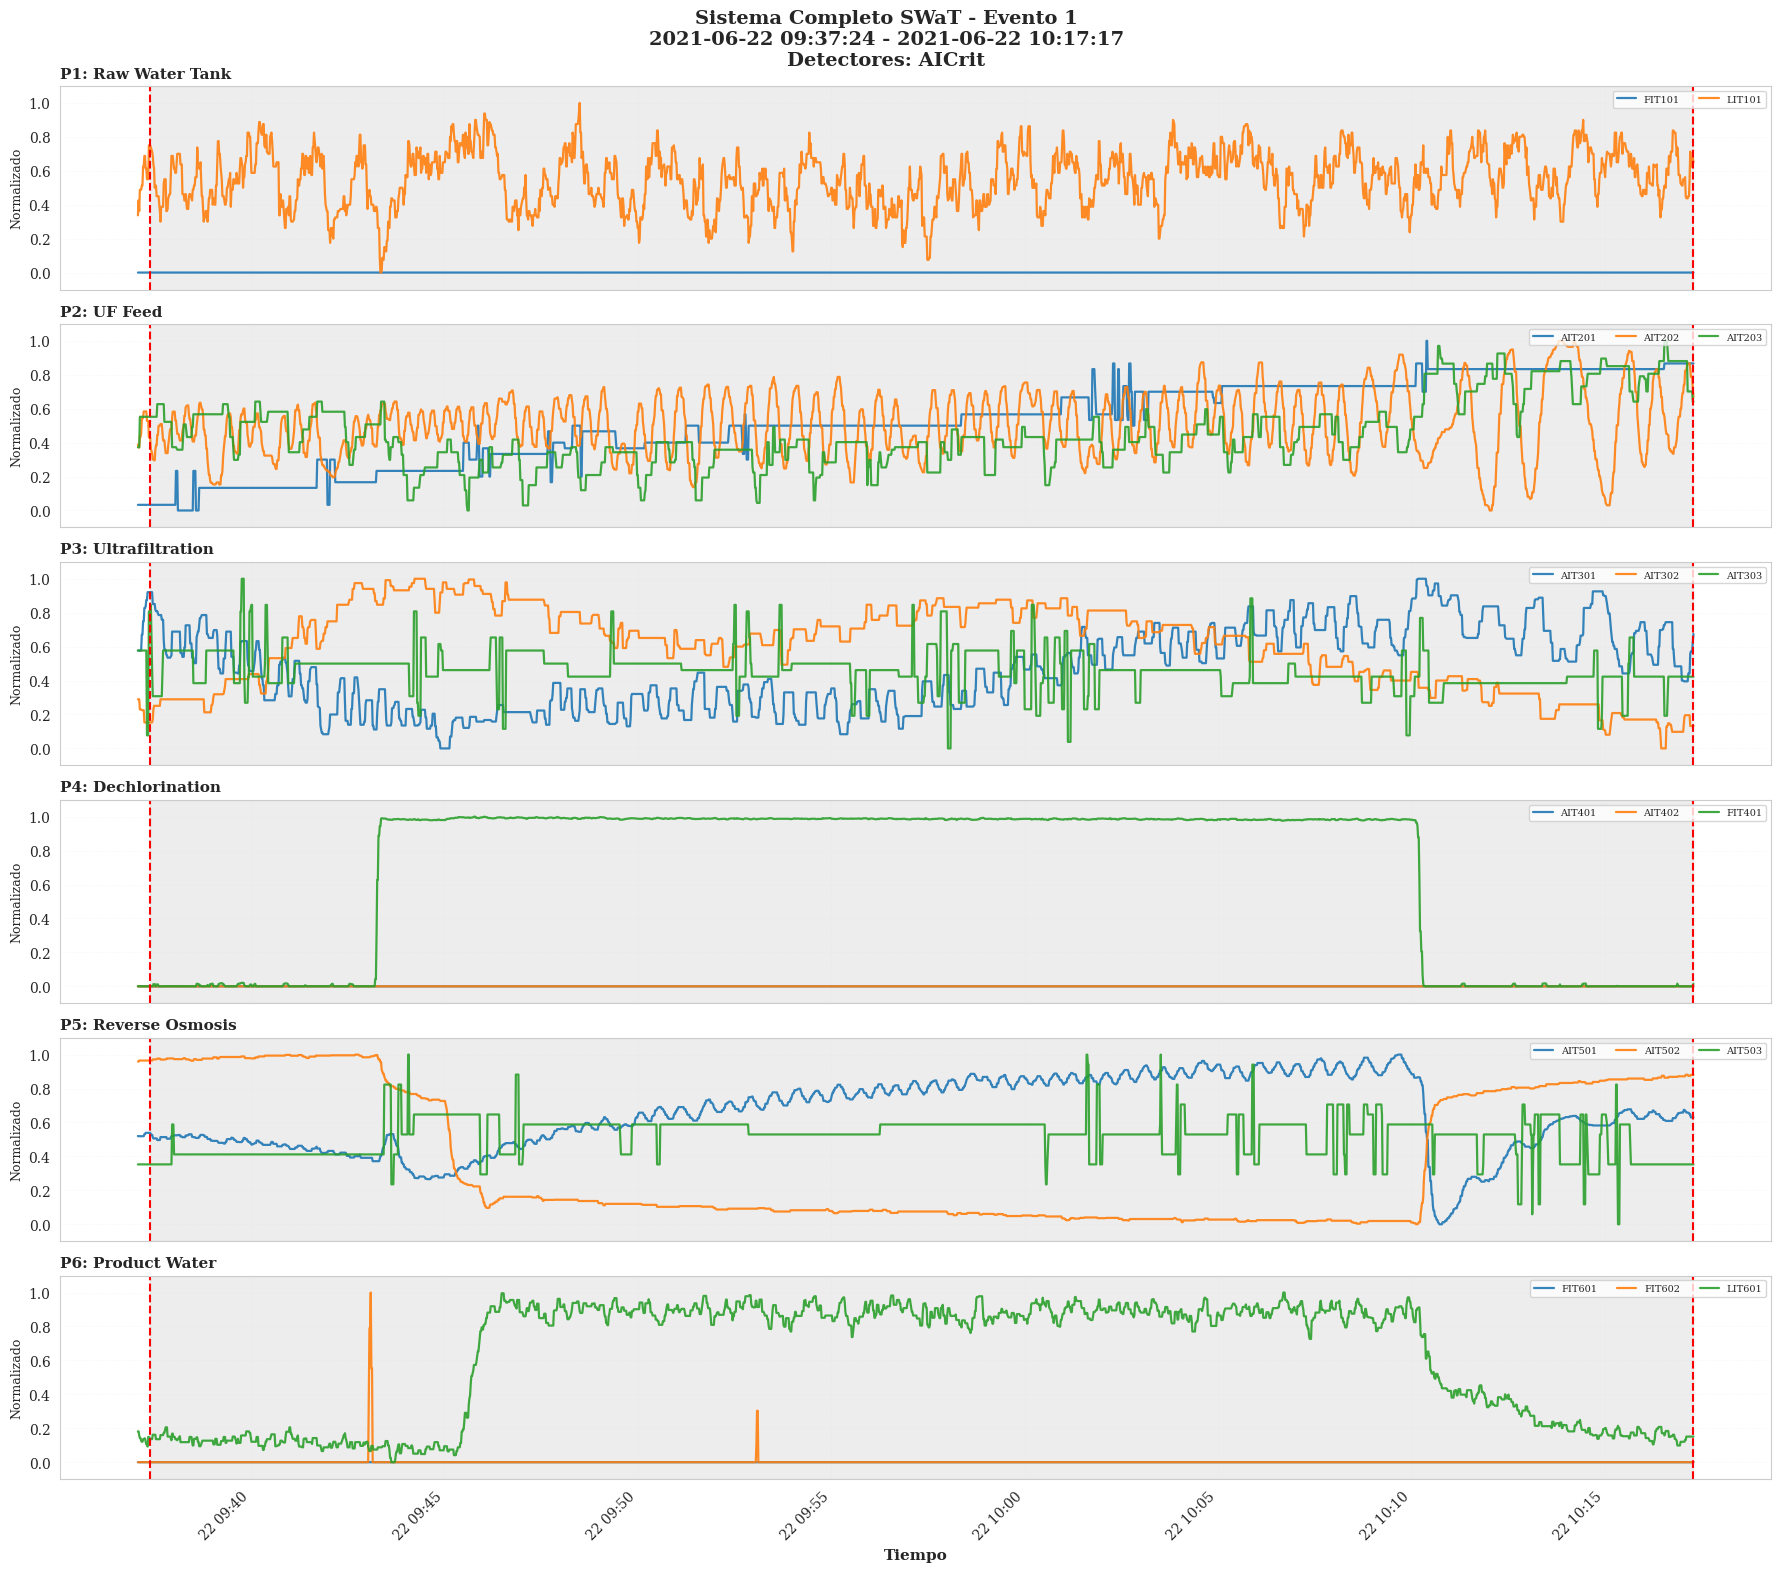

In [52]:
analyzer.plot_all_processes(event_id=1, seconds_before=130, seconds_after=130, mode='sensors')

### funciones para el modelamiento de DL

In [53]:
def create_sliding_windows(df, window_size, stride):
    """
    Crea ventanas deslizantes separando normal vs anomalía
    + metadata para mapeo ventana → evento
    
    Returns:
        windows_train: lista de ventanas normales
        windows_test: lista de ventanas con anomalías
        metadata_train: dict con info de cada ventana train
        metadata_test: dict con info de cada ventana test
    """
    if 'Block_ID' not in df.columns or 'Anomaly_Event' not in df.columns:
        print("Necesitas Block_ID y Anomaly_Event")
        return None, None, None, None
    
    windows_train = []
    windows_test = []
    metadata_train = []
    metadata_test = []
    
    train_idx = 0
    test_idx = 0
    
    # Procesar cada bloque
    for block_id in sorted(df['Block_ID'].unique()):
        block_data = df[df['Block_ID'] == block_id].copy()
        
        # Crear ventanas deslizantes
        for i in range(0, len(block_data) - window_size + 1, stride):
            window = block_data.iloc[i:i+window_size]
            
            # Metadata común
            meta = {
                'block_id': block_id,
                'start_time': window.index[0],
                'end_time': window.index[-1],
                'start_idx_in_block': i,
                'anomaly_event': int(window['Anomaly_Event'].max()),
                'has_anomaly': bool(window['Anomaly'].any()),
                'n_anomaly_records': int(window['Anomaly'].sum())
            }
            
            # Separar train/test
            if window['Anomaly_Event'].max() > 0:
                meta['window_idx'] = test_idx
                meta['split'] = 'test'
                windows_test.append(window)
                metadata_test.append(meta)
                test_idx += 1
            else:
                meta['window_idx'] = train_idx
                meta['split'] = 'train'
                windows_train.append(window)
                metadata_train.append(meta)
                train_idx += 1
    
    print(f"Ventanas train (normales): {len(windows_train)}")
    print(f"Ventanas test (con anomalías): {len(windows_test)}")
    
    if len(windows_train) > 0:
        total_train_records = sum(len(w) for w in windows_train)
        print(f"Registros totales en train: {total_train_records}")
    
    if len(windows_test) > 0:
        total_test_records = sum(len(w) for w in windows_test)
        anomaly_records = sum((w['Anomaly'] == 1).sum() for w in windows_test)
        print(f"Registros totales en test: {total_test_records}")
        print(f"Registros con anomalía en test: {anomaly_records}")
        
        # Info de eventos
        unique_events = set(m['anomaly_event'] for m in metadata_test)
        print(f"Eventos únicos en test: {len(unique_events)}")
    
    return windows_train, windows_test, metadata_train, metadata_test

In [54]:
def prepare_data_model(windows_train, windows_test):
    """
    Prepara datos con normalización diferenciada para sensores y actuadores
    """
    # Definir features por tipo
    continuous_features = [
        'FIT101', 'LIT101',
        'AIT201', 'AIT202', 'AIT203', 'FIT201',
        'AIT301', 'AIT302', 'AIT303', 'DPIT301', 'FIT301', 'LIT301',
        'AIT401', 'AIT402', 'FIT401', 'LIT401',
        'AIT501', 'AIT502', 'AIT503', 'AIT504',
        'FIT501', 'FIT502', 'FIT503', 'FIT504',
        'PIT501', 'PIT502', 'PIT503',
        'FIT601', 'FIT602', 'LIT601', 'LIT602'
    ]
    
    binary_features = [
        'MV101', 'P101', 'P102',
        'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206',
        'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302',
        'P401', 'P402', 'P403', 'P404', 'UV401',
        'MV501', 'MV502', 'MV503', 'MV504', 'P501', 'P502',
        'P601', 'P602', 'P603'
    ]
    
    all_features = continuous_features + binary_features
    
    print(f"Features continuas: {len(continuous_features)}")
    print(f"Features binarias: {len(binary_features)}")
    print(f"Total features: {len(all_features)}")
    
    # Convertir ventanas a arrays
    X_train = np.array([w[all_features].values for w in windows_train])
    X_test = np.array([w[all_features].values for w in windows_test])
    
    print(f"\nX_train shape inicial: {X_train.shape}")
    print(f"X_test shape inicial: {X_test.shape}")
    
    # Separar continuos y binarios
    n_continuous = len(continuous_features)
    
    X_train_cont = X_train[:, :, :n_continuous]
    X_train_bin = X_train[:, :, n_continuous:]
    
    X_test_cont = X_test[:, :, :n_continuous]
    X_test_bin = X_test[:, :, n_continuous:]
    
    # Normalizar solo features continuas
    scaler = StandardScaler()
    
    n_samples_train, window_size, _ = X_train_cont.shape
    X_train_cont_reshaped = X_train_cont.reshape(-1, n_continuous)
    X_train_cont_scaled = scaler.fit_transform(X_train_cont_reshaped)
    X_train_cont = X_train_cont_scaled.reshape(n_samples_train, window_size, n_continuous)
    
    n_samples_test = X_test_cont.shape[0]
    X_test_cont_reshaped = X_test_cont.reshape(-1, n_continuous)
    X_test_cont_scaled = scaler.transform(X_test_cont_reshaped)
    X_test_cont = X_test_cont_scaled.reshape(n_samples_test, window_size, n_continuous)
    
    # Recombinar
    X_train_final = np.concatenate([X_train_cont, X_train_bin], axis=2)
    X_test_final = np.concatenate([X_test_cont, X_test_bin], axis=2)
    
    print(f"\nX_train final shape: {X_train_final.shape}")
    print(f"X_test final shape: {X_test_final.shape}")

    X_train_final = np.array(X_train_final, dtype=np.float32)
    X_test_final = np.array(X_test_final, dtype=np.float32)

    return X_train_final, X_test_final, scaler, all_features

In [55]:
def autoencoder(window_size, n_features):
    """
    AE básico
    Trata cada timestamp independientemente
    """
    model = tf.keras.Sequential([
        # Encoder
        tf.keras.layers.Flatten(input_shape=(window_size, n_features)), # 60s x 63 
        tf.keras.layers.Dense(1024, activation='tanh'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(256, activation='tanh'),
        
        # Latent
        tf.keras.layers.Dense(64, activation='tanh'),  
        
        # Decoder
        tf.keras.layers.Dense(256, activation='tanh'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1024, activation='tanh'),
        tf.keras.layers.Dense(window_size * n_features, activation='linear'),
        tf.keras.layers.Reshape((window_size, n_features))
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', 
                  metrics=['mae'])
    
    return model

In [56]:
def lstm_autoencoder(window_size, n_features):
    """
    LSTM-Autoencoder robusto basado en Paper 1 + Paper 2
    
    Arquitectura:
    - Encoder: LSTM(128) + Dropout + LSTM(64)
    - Latent: 64 dimensions
    - Decoder: LSTM(64) + Dropout + LSTM(128)
    """
    model = tf.keras.Sequential([
        # Encoder
        tf.keras.layers.LSTM(
            128, 
            activation='tanh',
            return_sequences=True,
            input_shape=(window_size, n_features),
            name='encoder_lstm_1'
        ),
        tf.keras.layers.Dropout(0.2, name='encoder_dropout'),
        
        tf.keras.layers.LSTM(
            64,
            activation='tanh',
            return_sequences=False,
            name='encoder_lstm_2'
        ),
        
        # Latent space to sequence
        tf.keras.layers.RepeatVector(window_size, name='repeat_vector'),
        
        # Decoder
        tf.keras.layers.LSTM(
            64,
            activation='tanh',
            return_sequences=True,
            name='decoder_lstm_1'
        ),
        tf.keras.layers.Dropout(0.2, name='decoder_dropout'),
        
        tf.keras.layers.LSTM(
            128,
            activation='tanh',
            return_sequences=True,
            name='decoder_lstm_2'
        ),
        
        # Output
        tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(n_features),
            name='output'
        )
    ])
    
    # Compilar con MSE (Paper 2)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

In [57]:
def cnn_autoencoder(window_size, n_features, use_pooling=False):
    """
    CNN Autoencoder mejorado
    - Sin MaxPooling (usa stride en Conv1D)
    - GELU activation
    - Residual connections
    """
    inputs = tf.keras.Input(shape=(window_size, n_features))
    
    if use_pooling:
        # Opción 1: Conv + MaxPooling
        x = tf.keras.layers.Conv1D(
            filters=128,
            kernel_size=5,
            strides=1,  # Sin stride
            padding='same',
            activation='gelu'
        )(inputs)
        x = tf.keras.layers.MaxPooling1D(pool_size=2, padding='same')(x)  # 60→30
    else:
        # Opción 2: Conv con stride (sin pooling)
        x = tf.keras.layers.Conv1D(
            filters=128,
            kernel_size=5,
            strides=2,  # Reduce 60→30 directamente
            padding='same',
            activation='gelu'
        )(inputs)
    
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding='same',
        activation='gelu'
    )(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    # Flatten para latent space
    x = tf.keras.layers.Flatten()(x)
    latent = tf.keras.layers.Dense(64, activation='gelu')(x)
    
    x = tf.keras.layers.Dense(30 * 64, activation='gelu')(latent)
    x = tf.keras.layers.Reshape((30, 64))(x)
    
    x = tf.keras.layers.Conv1D(
        filters=128,
        kernel_size=3,
        padding='same',
        activation='gelu'
    )(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    if use_pooling:
        # Opción 1: UpSampling + Conv
        x = tf.keras.layers.UpSampling1D(size=2)(x)  # 30→60
        x = tf.keras.layers.Conv1D(
            filters=128,
            kernel_size=5,
            padding='same',
            activation='gelu'
        )(x)
    else:
        # Opción 2: Conv1DTranspose (mejor reconstrucción)
        x = tf.keras.layers.Conv1DTranspose(
            filters=128,
            kernel_size=5,
            strides=2,  # 30→60
            padding='same',
            activation='gelu'
        )(x)
    
    # Output layer
    outputs = tf.keras.layers.Conv1D(
        filters=n_features,
        kernel_size=5,
        padding='same',
        activation='linear'
    )(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

In [58]:
def transformer(window_size, n_features, d_model=128, num_heads=8, num_layers=6):
    """
    Transformer Autoencoder para detección de anomalías
    
    Arquitectura:
    - Encoder: Transformer blocks (self-attention)
    - Latent: Representación comprimida
    - Decoder: Transformer blocks inversos
    """
    
    # Input
    inputs = tf.keras.Input(shape=(window_size, n_features))
    
    # Proyección inicial a d_model
    x = tf.keras.layers.Dense(d_model)(inputs)  # (60, 67) → (60, 256)
    
    # Positional encoding (crucial para orden temporal)
    positions = tf.range(start=0, limit=window_size, delta=1)
    pos_encoding = tf.keras.layers.Embedding(
        input_dim=window_size, 
        output_dim=d_model
    )(positions)
    x = x + pos_encoding
    
    # Encoder: Transformer blocks
    for _ in range(num_layers):
        # Multi-head self-attention
        attn_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )(x, x)
        attn_output = tf.keras.layers.Dropout(0.1)(attn_output)
        x = tf.keras.layers.LayerNormalization()(x + attn_output)
        
        # Feed-forward
        ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(d_model * 2, activation='relu'),
            tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(d_model)
        ])
        ffn_output = ffn(x)
        x = tf.keras.layers.LayerNormalization()(x + ffn_output)
    
    # Compresión a latent (opcional, para bottleneck)
    encoded = tf.keras.layers.GlobalAveragePooling1D()(x)  # (256,)
    latent = tf.keras.layers.Dense(64, activation='tanh')(encoded)  # (64,)
    
    # Expansión desde latent
    decoded = tf.keras.layers.Dense(d_model)(latent)  # (64,) → (256,)
    decoded = tf.keras.layers.RepeatVector(window_size)(decoded)  # (60, 256)
    
    # Decoder: Transformer blocks
    for _ in range(num_layers):
        attn_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )(decoded, decoded)
        attn_output = tf.keras.layers.Dropout(0.1)(attn_output)
        decoded = tf.keras.layers.LayerNormalization()(decoded + attn_output)
        
        ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(d_model * 2, activation='relu'),
            tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(d_model)
        ])
        ffn_output = ffn(decoded)
        decoded = tf.keras.layers.LayerNormalization()(decoded + ffn_output)
    
    # Output: proyectar de vuelta a n_features
    outputs = tf.keras.layers.Dense(n_features)(decoded)  # (60, 256) → (60, 67)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

In [59]:
def train_model(model, X_train, epochs=40, batch_size=32, validation_split=0.1):
    """
    Entrena el modelo con callbacks
    """
    # Callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
    
    # Entrenar
    history = model.fit(
        X_train, X_train,  # Autoencoder: input = output
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    return history

In [60]:
def plot_training_history(history, model_name):
    """
    Visualiza métricas de entrenamiento y guarda la figura del entrenamiento.
    """
    # Crear carpeta si no existe
    save_dir = "history"
    os.makedirs(save_dir, exist_ok=True)

    # Crear figura
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    ax = axes[0]
    ax.plot(history.history['loss'], label='Train Loss')
    ax.plot(history.history['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title('Pérdida durante Entrenamiento')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # MAE
    ax = axes[1]
    ax.plot(history.history['mae'], label='Train MAE')
    ax.plot(history.history['val_mae'], label='Val MAE')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE')
    ax.set_title('MAE durante Entrenamiento')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()

    # Guardar imagen
    fig_path = os.path.join(save_dir, f"training_history_{model_name}.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')

In [61]:
def evaluate_and_detect(model, X_train, X_test, percentile=85, metric='MAE'):
    """
    Evalúa el modelo y detecta anomalías usando umbral
    Calcula métricas de clasificación por ventana
    
    Args:
        model: Modelo entrenado
        X_train: Datos de entrenamiento (normales)
        X_test: Datos de test (anómalos)
        percentile: Percentil para establecer umbral
        metric: 'MAE' o 'MedAE'
    """
    # Predicciones
    print("\nCalculando reconstrucciones...")
    train_pred = model.predict(X_train, verbose=0) # ya estan entrenados los modelos
    test_pred = model.predict(X_test, verbose=0)
    
    # Calcular error según métrica
    if metric == 'MAE':
        train_error = np.mean(np.abs(train_pred - X_train), axis=(1, 2))
        test_error = np.mean(np.abs(test_pred - X_test), axis=(1, 2))
    elif metric == 'MedAE':
        train_error = np.median(np.abs(train_pred - X_train), axis=(1, 2))
        test_error = np.median(np.abs(test_pred - X_test), axis=(1, 2))
    else:
        raise ValueError(f"Métrica '{metric}' no soportada. Use 'MAE' o 'MedAE'")
    
    # Establecer umbral
    threshold = np.percentile(train_error, percentile)
    
    print(f"\nMétrica: {metric}")
    print(f"Umbral de anomalía (P{percentile}): {threshold:.6f}")
    
    # Ground truth y predicciones
    y_true = np.concatenate([
        np.zeros(len(train_error)),  # Train = normal (0)
        np.ones(len(test_error))     # Test = anómalo (1)
    ])
    
    y_pred = np.concatenate([
        (train_error > threshold).astype(int),
        (test_error > threshold).astype(int)
    ])
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Métricas
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
        
    metrics = {
        'metric_type': metric,
        'threshold': threshold,
        'percentile': percentile,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
    }
    
    return train_error, test_error, threshold, train_pred, test_pred, metrics

In [62]:
def plot_results(train_error, test_error, threshold, metrics, model_name):
    """
    Visualiza resultados de detección y guarda en carpeta results
    
    Args:
        train_error: Errores de reconstrucción en train
        test_error: Errores de reconstrucción en test
        threshold: Umbral de detección
        metrics: Diccionario con métricas
        model_name: Nombre del modelo para guardar archivos
    """
    # Crear carpeta results si no existe
    os.makedirs('results', exist_ok=True)
    
    # Obtener métrica usada
    metric_type = metrics.get('metric_type', 'MAE')
    
    # Crear figura con 3 subplots
    fig = plt.figure(figsize=(18, 5))
    gs = fig.add_gridspec(1, 2, hspace=0.3, wspace=0.3)
    
    # ==================== 1. DISTRIBUCIÓN DE ERRORES ====================
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(train_error, bins=50, alpha=0.7, label='Train (Normal)', color='blue', edgecolor='black')
    ax1.hist(test_error, bins=50, alpha=0.7, label='Test (Anómalo)', color='red', edgecolor='black')
    ax1.axvline(threshold, color='black', linestyle='--', linewidth=2, 
                label=f'Umbral={threshold:.4f}')
    ax1.set_xlabel(f'Error de Reconstrucción ({metric_type})', fontsize=11)
    ax1.set_ylabel('Frecuencia', fontsize=11)
    ax1.set_title(
        f"Distribución de Errores ({metric_type})\n"
        f"F1={metrics['f1']:.3f} | Prec={metrics['precision']:.3f} | Rec={metrics['recall']:.3f}",
        fontsize=12, fontweight='bold'
    )
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # ==================== 2. ERRORES EN SECUENCIA ====================
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(test_error, alpha=0.7, label='Error Test', linewidth=1, color='darkblue')
    ax2.axhline(threshold, color='red', linestyle='--', linewidth=2, label='Umbral')
    ax2.fill_between(range(len(test_error)), 0, threshold, alpha=0.2, color='green', label='Normal')
    ax2.fill_between(range(len(test_error)), threshold, test_error.max(), 
                     alpha=0.2, color='red', label='Anomalía')
    ax2.set_xlabel('Ventana', fontsize=11)
    ax2.set_ylabel(f'Error de Reconstrucción ({metric_type})', fontsize=11)
    ax2.set_title('Errores en Test (Secuencia)', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # Título general
    fig.suptitle(f'Resultados de Detección - {model_name}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    # Guardar figura
    filename = f'results/{model_name}_results.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')

In [63]:
def aggregate_reconstructions(X_data, X_pred, metadata, windows, scaler, features, event_id=None, method='median'):
    """
    Convierte ventanas superpuestas en serie temporal continua
    Versión generalizada para train, test, o eventos específicos
    
    Args:
        X_data: array normalizado (n, 60, 67)
        X_pred: predicciones (n, 60, 67)
        metadata: lista de metadata
        windows: lista de DataFrames
        scaler: StandardScaler
        features: lista de nombres
        event_id: None para todo, o ID específico para filtrar
        method: 'mean', 'median', 'center'
    
    Returns:
        df_original: DataFrame con valores originales
        df_reconstructed: DataFrame con valores reconstruidos
    """
    # Filtrar por evento si se especifica
    if event_id is not None:
        indices = [i for i, meta in enumerate(metadata) if meta.get('anomaly_event', 0) == event_id]
        if len(indices) == 0:
            print(f"No se encontraron ventanas para el evento {event_id}")
            return None, None
        print(f"Evento {event_id}: {len(indices)} ventanas")
    else:
        indices = list(range(len(metadata)))
        print(f"Procesando todas las ventanas: {len(indices)}")
    
    # Features continuas
    continuous_features = [
        'FIT101', 'LIT101',
        'AIT201', 'AIT202', 'AIT203', 'FIT201',
        'AIT301', 'AIT302', 'AIT303', 'DPIT301', 'FIT301', 'LIT301',
        'AIT401', 'AIT402', 'FIT401', 'LIT401',
        'AIT501', 'AIT502', 'AIT503', 'AIT504',
        'FIT501', 'FIT502', 'FIT503', 'FIT504',
        'PIT501', 'PIT502', 'PIT503',
        'FIT601', 'FIT602', 'LIT601', 'LIT602'
    ]
    n_continuous = len(continuous_features)
    
    # Recopilar timestamps únicos
    all_timestamps = []
    for window_idx in indices:
        window_df = windows[window_idx]
        all_timestamps.extend(window_df.index.tolist())
    
    unique_timestamps = sorted(set(all_timestamps))
    print(f"Timestamps únicos: {len(unique_timestamps)}")
    print(f"Rango: {unique_timestamps[0]} a {unique_timestamps[-1]}")
    
    # Acumuladores
    original_accumulator = {ts: {feat: [] for feat in features} for ts in unique_timestamps}
    reconstructed_accumulator = {ts: {feat: [] for feat in features} for ts in unique_timestamps}
    
    # Procesar ventanas
    for window_idx in indices:
        window_df = windows[window_idx]
        window_timestamps = window_df.index.tolist()
        
        # Arrays normalizados
        X_original = X_data[window_idx]
        X_reconstructed = X_pred[window_idx]
        
        # Desnormalizar
        X_orig_cont = X_original[:, :n_continuous]
        X_orig_bin = X_original[:, n_continuous:]
        X_recon_cont = X_reconstructed[:, :n_continuous]
        X_recon_bin = X_reconstructed[:, n_continuous:]
        
        X_orig_cont_denorm = scaler.inverse_transform(X_orig_cont)
        X_recon_cont_denorm = scaler.inverse_transform(X_recon_cont)
        
        X_orig_denorm = np.concatenate([X_orig_cont_denorm, X_orig_bin], axis=1)
        X_recon_denorm = np.concatenate([X_recon_cont_denorm, X_recon_bin], axis=1)
        
        # Acumular
        for i, ts in enumerate(window_timestamps):
            for j, feat in enumerate(features):
                original_accumulator[ts][feat].append(X_orig_denorm[i, j])
                reconstructed_accumulator[ts][feat].append(X_recon_denorm[i, j])
    
    # Agregar
    if method == 'mean':
        agg_func = np.mean
    elif method == 'median':
        agg_func = np.median
    elif method == 'center':
        agg_func = lambda x: x[len(x)//2] if len(x) > 0 else np.nan
    else:
        raise ValueError(f"Método '{method}' no reconocido")
    
    # Construir DataFrames
    original_data = {feat: [] for feat in features}
    reconstructed_data = {feat: [] for feat in features}
    
    for ts in unique_timestamps:
        for feat in features:
            original_data[feat].append(agg_func(original_accumulator[ts][feat]))
            reconstructed_data[feat].append(agg_func(reconstructed_accumulator[ts][feat]))
    
    df_original = pd.DataFrame(original_data, index=unique_timestamps)
    df_reconstructed = pd.DataFrame(reconstructed_data, index=unique_timestamps)
    
    df_original.index.name = 'Timestamp'
    df_reconstructed.index.name = 'Timestamp'
    
    print(f"\nDataFrames creados:")
    print(f"  Shape: {df_original.shape}")
    print(f"  Rango: {df_original.index[0]} a {df_original.index[-1]}")
    
    # MAE global
    mae_global = np.mean(np.abs(df_original.values - df_reconstructed.values))
    print(f"  MAE global: {mae_global:.4f}")
    
    return df_original, df_reconstructed

In [64]:
def train_fit(X_data, X_pred, metadata, windows, scaler, features, model_name):
    df_original_train, df_reconstructed_train = aggregate_reconstructions(
        X_data=X_data,
        X_pred=X_pred,
        metadata=metadata,
        windows=windows,
        scaler=scaler,
        features=features,
        event_id=None  # None = todas las ventanas
    )

    df_original_train_ = df_original_train.head(10000)
    df_reconstructed_train_ = df_reconstructed_train.head(10000)
    list_sensor = ['AIT201', 'AIT202', 'AIT203', 'FIT201']

    fig, axes = plt.subplots(
        len(list_sensor),
        1,
        figsize=(10, 3 * len(list_sensor)),
        sharex=True
    )

    for ax, sensor in zip(axes, list_sensor):

        # Línea original: protagonista
        ax.plot(
            df_original_train_.index,
            df_original_train_[sensor],
            '-',
            label='Original',
            linewidth=2.2
        )

        # Línea reconstruida: contraste suave
        ax.plot(
            df_reconstructed_train_.index,
            df_reconstructed_train_[sensor],
            '--',
            label='Reconstruido',
            linewidth=1.6
        )

        ax.set_ylabel(sensor, fontsize=11)
        ax.set_title(f'Recontrucción en datos de entrenamiento – {sensor}', fontsize=12)

        # Grid académico
        ax.grid(True, linewidth=0.4, color='0.85')

        # Leyenda sobria
        ax.legend(
            loc='upper right',
            frameon=True,
            facecolor='white',
            edgecolor='0.8',
            fontsize=8
        )

    plt.xlabel('Timestamp', fontsize=11)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    filename = f'results/{model_name}_train_fit.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')

In [65]:
def anomaly_reconstructed(X_data, X_pred, metadata, windows, scaler, features, model_name):
    # center, median, mean
    _, df_reconstructed_test = aggregate_reconstructions(
        X_data=X_data,
        X_pred=X_pred,
        metadata=metadata,
        windows=windows,
        scaler=scaler,
        features=features,
        event_id=1
    )

    analyzer.plot_all_processes_reconstruction(event_id=1, df_reconstructed=df_reconstructed_test, model_name=model_name, seconds_before=130, seconds_after=130, mode='sensors')

    analyzer.plot_all_processes_reconstruction(event_id=1, df_reconstructed=df_reconstructed_test, model_name=model_name, seconds_before=130, seconds_after=130, mode='actuators')

## PIPELINE COMPLETO

In [78]:
def create_model(model_name, window_size, n_features):
    """Factory para crear modelos"""
    models = {
        'autoencoder': autoencoder(window_size, n_features), # no complejizar y solo recontruir importa
        'lstm_autoencoder': lstm_autoencoder(window_size, n_features), # temporalidad importa, maquina que guarda memoria pero corto plazista 
        'cnn_autoencoder': cnn_autoencoder(window_size, n_features, use_pooling=False), # las correlaciones locales importan 
        'cnn_autoencoder_limited': cnn_autoencoder(window_size, n_features, use_pooling=True), # las correlaciones locales importan pero perdemos info con polling
        'transformer': transformer(window_size, n_features), 
        'transformer_limited': transformer(window_size, n_features, 128, 4, 2),
        'transformer_ultra_limited': transformer(window_size, n_features, 64, 2, 2) 
    }
    return models[model_name]

In [82]:
EXPERIMENT_CONFIG = {
    #'strides': [1, 15, 30],
    'strides': [30],
    #'models': ['autoencoder', 'lstm_autoencoder', 'cnn_autoencoder', 'cnn_autoencoder_limited'],
    'models': ['lstm_autoencoder', 'cnn_autoencoder_limited'],
    'epochs': 100,
    'batch_size': 32,
    'validation_split': 0.1,
    'percentile': 85,
    'window_size': 60
}

In [83]:
def run_experiment(df, config, force_retrain=False):
    """
    Ejecuta todos los experimentos y genera tabla comparativa
    
    Args:
        df: DataFrame con datos SWaT
        config: Diccionario con configuración
        force_retrain: Si True, reentrena aunque exista el modelo
    
    Returns:
        results_df: DataFrame con resultados comparativos
    """
    
    results = []
    
    for stride in config['strides']:
        print(f"\n{'='*80}")
        print(f"STRIDE = {stride}")
        print(f"{'='*80}\n")
        
        # Crear ventanas (solo una vez por stride)
        windows_train, windows_test, metadata_train, metadata_test = create_sliding_windows(
            df, 
            window_size=config['window_size'], 
            stride=stride
        )
        
        X_train, X_test, scaler, features = prepare_data_model(windows_train, windows_test)
        
        window_size = X_train.shape[1]
        n_features = X_train.shape[2]
        
        for model_name in config['models']:
            print(f"\n--- Modelo: {model_name} | Stride: {stride} ---")
            
            model_path = f'models/{model_name}_stride{stride}.keras'
            
            # Verificar si ya existe el modelo
            if Path(model_path).exists() and not force_retrain:
                print(f"⚠️  Cargando modelo existente: {model_path}")
                model = tf.keras.models.load_model(model_path)
                train_time = None  # No disponible si se carga
                history = None
            else:
                # Crear modelo
                model = create_model(model_name, window_size, n_features)
                
                # Entrenar y medir tiempo
                start_time = time.time()
                history = train_model(
                    model, 
                    X_train, 
                    epochs=config['epochs'], 
                    batch_size=config['batch_size'], 
                    validation_split=config['validation_split']
                )
                train_time = time.time() - start_time
                
                # Guardar modelo
                model.save(model_path)
                print(f"✅ Modelo guardado: {model_path}")
                
                # Guardar gráfica de entrenamiento
                plot_training_history(
                    history, 
                    f"{model_name}_stride{stride}"
                )
            
            # Contar parámetros
            total_params = model.count_params()
            
            # Evaluar con MAE
            #train_error_mae, test_error_mae, threshold_mae, _, _, metrics_mae = evaluate_and_detect(
            #    model, X_train, X_test, percentile=config['percentile'], metric='MAE'
            #)
            
            # Evaluar con MedAE
            #train_error_medae, test_error_medae, threshold_medae, train_pred, test_pred, metrics_medae = evaluate_and_detect(
            #    model, X_train, X_test, percentile=config['percentile'], metric='MedAE'
            #)
            
            # Guardar grafica de distribucion de errores
            #plot_results(
            #    train_error_mae, test_error_mae, threshold_mae, metrics_mae, 
            #    f"{model_name}_stride{stride}_MAE"
            #)
            
            #plot_results(
            #    train_error_medae, test_error_medae, threshold_medae, metrics_medae, 
            #    f"{model_name}_stride{stride}_MedAE"
            #)

            # recontruccion de las primeros 10.000 segundos de las ventanas de train para el proceso P2
            #train_fit(X_train, train_pred, metadata_train, windows_train, scaler, features, 
            #          f"{model_name}_stride{stride}"
            #          )
            
            #anomaly_reconstructed(X_test, test_pred, metadata_test, windows_test, scaler, features,
            #                      f"{model_name}_stride{stride}"
            #                      )

            # Guardar resultados
            result = {
                'model': model_name,
                'stride': stride,
                #'f1_mae': metrics_mae['f1'],
                #'f1_medae': metrics_medae['f1'],
                #'precision_mae': metrics_mae['precision'],
                #'recall_mae': metrics_mae['recall'],
                #'precision_medae': metrics_medae['precision'],
                #'recall_medae': metrics_medae['recall'],
                #'threshold_mae': threshold_mae,
                #'threshold_medae': threshold_medae,
                'train_time_sec': train_time,
                'total_params': total_params,
                'n_train_windows': len(X_train),
                'n_test_windows': len(X_test)
            }
            
            results.append(result)


    # Crear DataFrame con resultados
    results_df = pd.DataFrame(results)
    
    # Formatear columnas
    results_df['train_time_min'] = results_df['train_time_sec'].apply(
        lambda x: f"{x/60:.2f}" if x is not None else "N/A"
    )
    results_df['params_k'] = results_df['total_params'] / 1000
    
    # Guardar tabla completa
    results_df.to_csv('results/experiment_results.csv', index=False)
    print(f"\n✅ Resultados guardados en: results/experiment_results.csv")
    
    return results_df


STRIDE = 30

Ventanas train (normales): 2440
Ventanas test (con anomalías): 1418
Registros totales en train: 146400
Registros totales en test: 85080
Registros con anomalía en test: 43318
Eventos únicos en test: 481
Features continuas: 31
Features binarias: 30
Total features: 61

X_train shape inicial: (2440, 60, 61)
X_test shape inicial: (1418, 60, 61)

X_train final shape: (2440, 60, 61)
X_test final shape: (1418, 60, 61)

--- Modelo: lstm_autoencoder | Stride: 30 ---
Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.6823 - mae: 0.5917 - val_loss: 0.9616 - val_mae: 0.6634 - learning_rate: 0.0010
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2759 - mae: 0.2984 - val_loss: 0.4110 - val_mae: 0.3292 - learning_rate: 0.0010
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2312 - mae: 0.2619 - val_loss: 0.3446 - val_mae: 0.2916 - learning_rate: 0.0010
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1953 - mae: 0.2265 - val_loss: 0.264

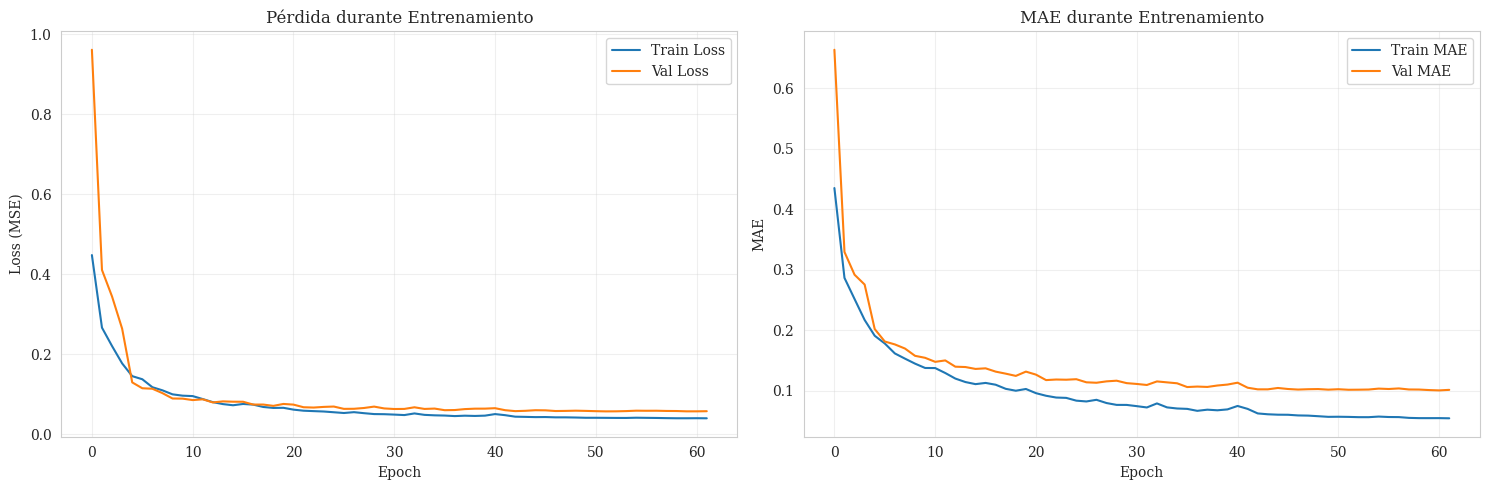

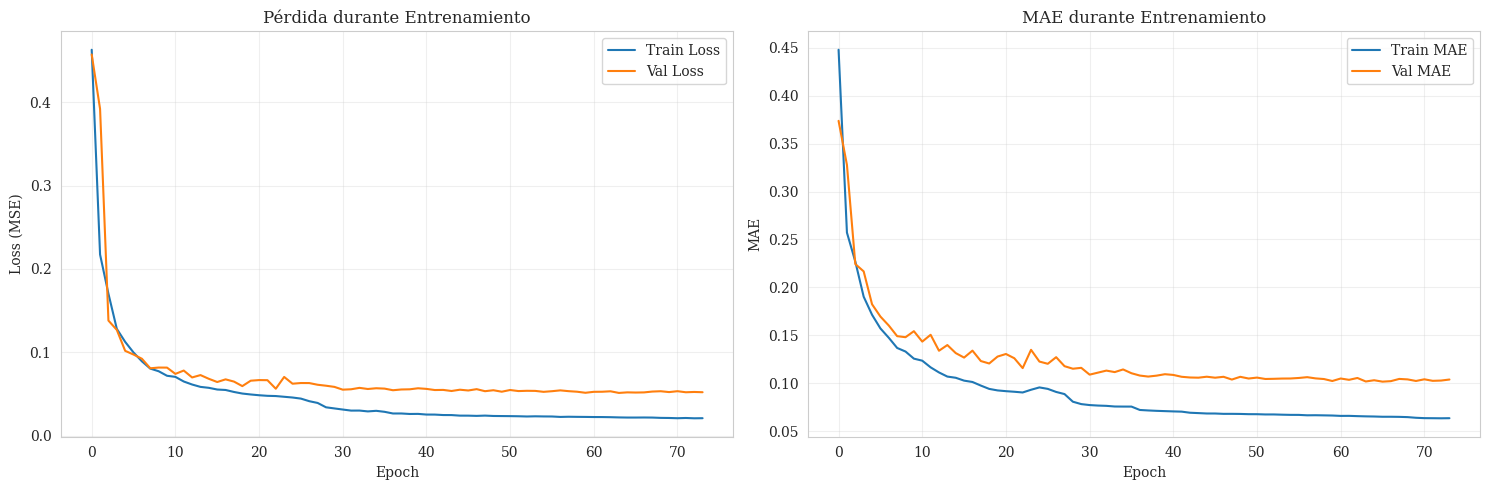

In [84]:
if __name__ == "__main__":
    # Ejecutar experimentos
    results_df = run_experiment(df_2021, EXPERIMENT_CONFIG, force_retrain=True)
    

In [85]:
!find . -maxdepth 2 -type f -print

./.config/.last_opt_in_prompt.yaml
./.config/gce
./.config/config_sentinel
./.config/default_configs.db
./.config/.last_survey_prompt.yaml
./.config/active_config
./.config/.last_update_check.json
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./results/experiment_results.csv
./results/transformer_stride30_MedAE_results.png
./results/transformer_stride30_MAE_results.png
./models/transformer_stride30.keras
./models/transformer_ultra_limited_stride30.keras
./models/cnn_autoencoder_limited_stride30.keras
./models/lstm_autoencoder_stride30.keras
./models/cnn_autoencoder_stride30.keras
./models/transformer_limited_stride30.keras
./history/training_history_transformer_ultra_limited_stride30.png
./history/training_history_cnn_autoencoder_stride30.png
./history/training_history_transformer_stride30.png
./history/training_history_transformer_limited_stride30.png
./history/training_history_cnn_autoencoder_limited_stride30.png
./history/training_history_lstm_autoencoder_